In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROJECT = Path.cwd().parent
PHASE2 = PROJECT / 'data' / 'phase2'
TAB = PROJECT / 'results' / 'phase2' / 'tables'
FIG = PROJECT / 'results' / 'phase2' / 'figures'

# Load densities
d = np.load(PHASE2 / 'phase2_densities.npz')
R = d['R_grid']
p_alm = d['p_almeida']
p_kde = d['p_kde']
q_cme = d['q_cme']
q_der = d['q_der']

# Load summary
summary = pd.read_csv(TAB / 'ep_decomposition_summary.csv')
print("--- EP Decomposition Summary ---")
print(summary.to_string(index=False))

--- EP Decomposition Summary ---
venue estimator  total_ep  downside_contrib  downside_share  mid_contrib  mid_share  upside_contrib  upside_share
  CME   almeida  0.142070         -0.021587       -0.151945    -0.257299  -1.811068        0.422963      2.977143
  DER   almeida  0.141743         -0.027825       -0.196308    -0.238499  -1.682613        0.410063      2.892993
  CME       kde  0.040734          0.002745        0.067383    -0.112836  -2.770046        0.151056      3.708324
  DER       kde  0.040408         -0.003494       -0.086461    -0.094037  -2.327202        0.138156      3.419054


#### 1. Physical vs Risk-Neutral Densities

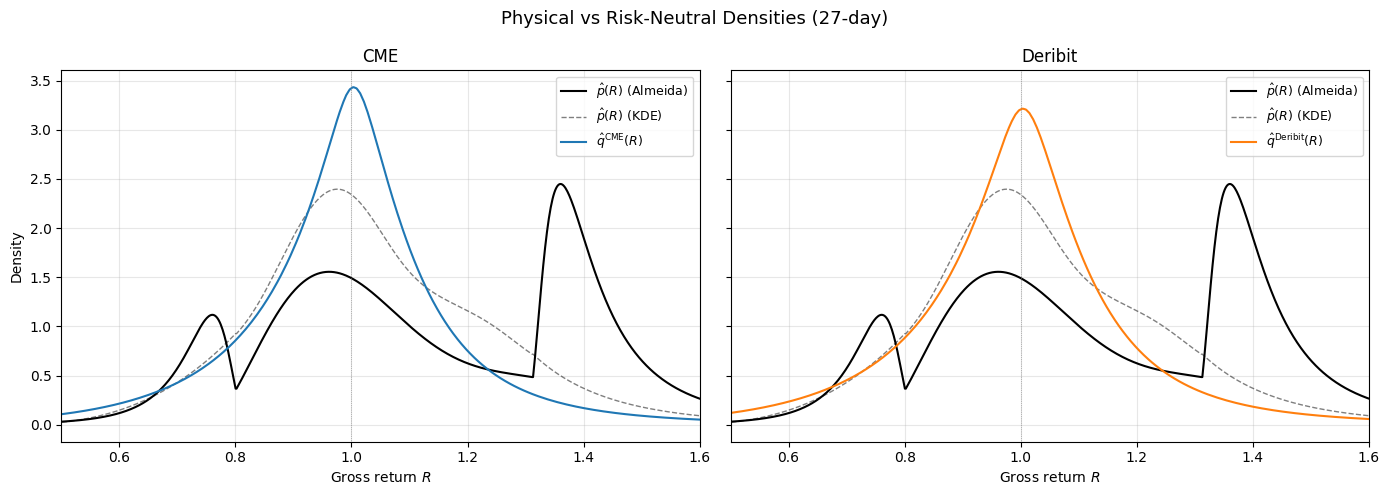

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (venue, q, color) in zip(axes, [('CME', q_cme, 'C0'), ('Deribit', q_der, 'C1')]):
    ax.plot(R, p_alm, 'k-', lw=1.5, label=r'$\hat{p}(R)$ (Almeida)')
    ax.plot(R, p_kde, 'k--', lw=1, alpha=0.5, label=r'$\hat{p}(R)$ (KDE)')
    ax.plot(R, q, color=color, lw=1.5, label=rf'$\hat{{q}}^{{\mathrm{{{venue}}}}}(R)$')
    ax.axvline(1.0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Gross return $R$')
    ax.set_xlim(0.5, 1.6)
    ax.set_title(venue)
    ax.legend(fontsize=9)
axes[0].set_ylabel('Density')
fig.suptitle('Physical vs Risk-Neutral Densities (27-day)', fontsize=13)
plt.tight_layout()
plt.show()

#### 2. EP Curve: CME vs Deribit

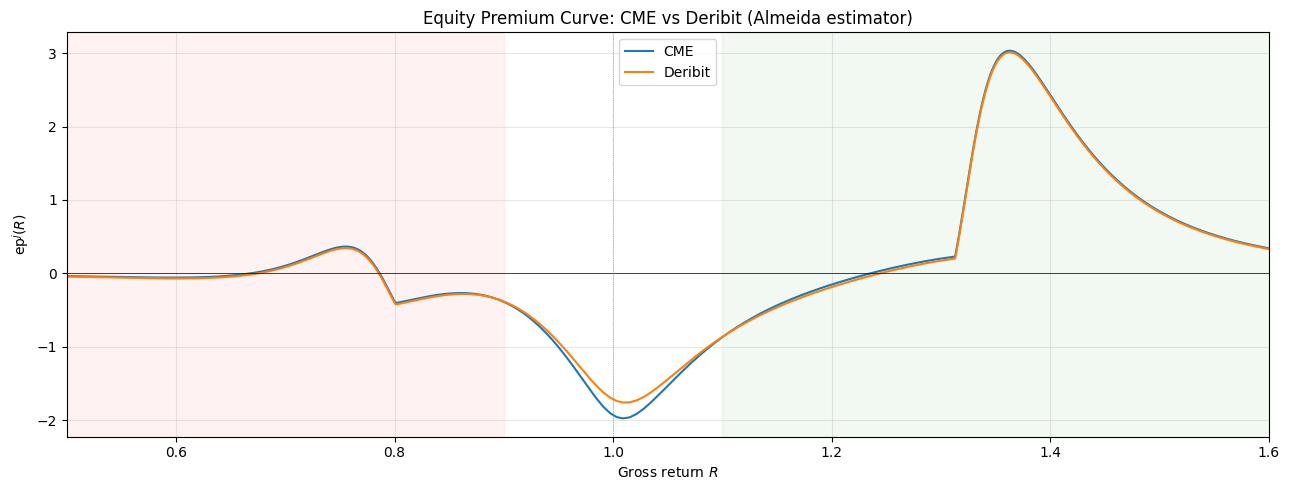

In [3]:
ep_cme = (p_alm - q_cme) * R
ep_der = (p_alm - q_der) * R

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(R, ep_cme, 'C0-', lw=1.5, label='CME')
ax.plot(R, ep_der, 'C1-', lw=1.5, label='Deribit')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(1.0, color='gray', lw=0.5, ls=':')
ax.axvspan(R[0], 0.90, alpha=0.05, color='red')
ax.axvspan(1.10, R[-1], alpha=0.05, color='green')
ax.set_xlabel('Gross return $R$')
ax.set_ylabel(r'$\mathrm{ep}^j(R)$')
ax.set_xlim(0.5, 1.6)
ax.set_title('Equity Premium Curve: CME vs Deribit (Almeida estimator)')
ax.legend()
plt.tight_layout()
plt.show()

#### 3. Cumulative EP

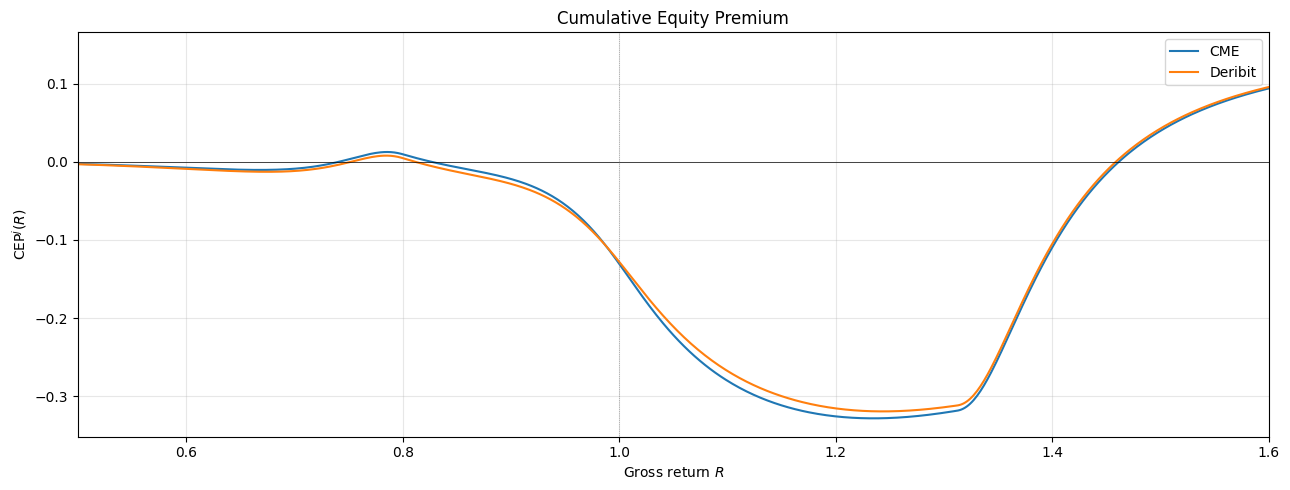

In [4]:
cep_cme = np.cumsum(np.diff(R, prepend=R[0]) * ep_cme)
cep_der = np.cumsum(np.diff(R, prepend=R[0]) * ep_der)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(R, cep_cme, 'C0-', lw=1.5, label='CME')
ax.plot(R, cep_der, 'C1-', lw=1.5, label='Deribit')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(1.0, color='gray', lw=0.5, ls=':')
ax.set_xlabel('Gross return $R$')
ax.set_ylabel(r'$\mathrm{CEP}^j(R)$')
ax.set_xlim(0.5, 1.6)
ax.set_title('Cumulative Equity Premium')
ax.legend()
plt.tight_layout()
plt.show()

#### 4. Unconditional Pricing Kernel

Under standard risk aversion this should be monotonically decreasing. A hump (local increase) in the small-negative-return region
is the anomaly documented by Almeida et al. (2026) on Deribit.

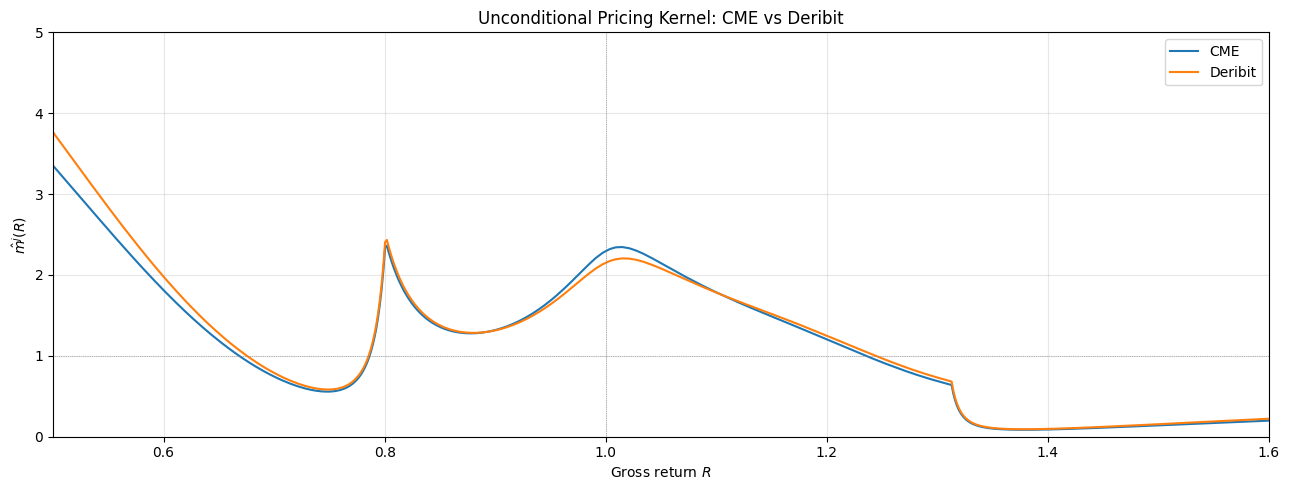

In [5]:
p_safe = np.maximum(p_alm, 1e-15)
k_cme = q_cme / p_safe
k_der = q_der / p_safe
k_cme[p_alm < 1e-15] = np.nan
k_der[p_alm < 1e-15] = np.nan

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(R, k_cme, 'C0-', lw=1.5, label='CME')
ax.plot(R, k_der, 'C1-', lw=1.5, label='Deribit')
ax.axhline(1.0, color='gray', lw=0.5, ls=':')
ax.axvline(1.0, color='gray', lw=0.5, ls=':')
ax.set_xlabel('Gross return $R$')
ax.set_ylabel(r'$\hat{m}^j(R)$')
ax.set_xlim(0.5, 1.6)
ax.set_ylim(0, 5)
ax.set_title('Unconditional Pricing Kernel: CME vs Deribit')
ax.legend()
plt.tight_layout()
plt.show()

#### 5. Regional Decomposition Summary

Decompose total EP into downside ($R < 0.90$), mid ($0.90 \leq R \leq 1.10$), and
upside ($R > 1.10$) contributions.

In [6]:
summary_pivot = summary.pivot(index='venue', columns='estimator',
                               values=['total_ep', 'downside_share', 'mid_share', 'upside_share'])
print(summary_pivot.round(3).to_string())

          total_ep        downside_share        mid_share        upside_share       
estimator  almeida    kde        almeida    kde   almeida    kde      almeida    kde
venue                                                                               
CME          0.142  0.041         -0.152  0.067    -1.811 -2.770        2.977  3.708
DER          0.142  0.040         -0.196 -0.086    -1.683 -2.327        2.893  3.419


#### 6. Estimator Robustness: Almeida vs KDE

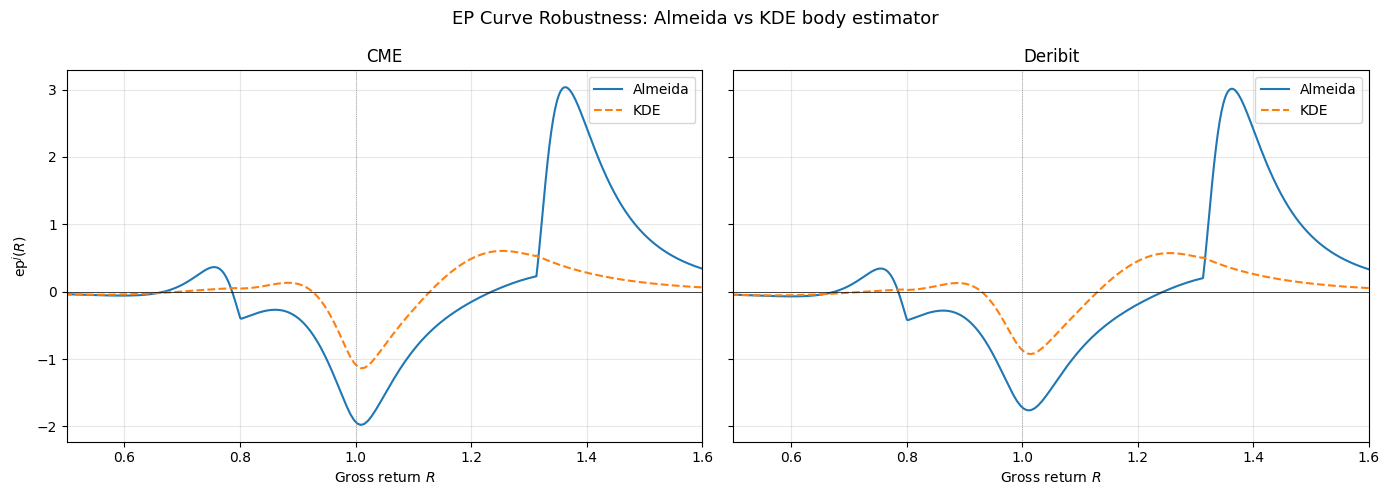

In [7]:
ep_cme_kde = (p_kde - q_cme) * R
ep_der_kde = (p_kde - q_der) * R

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (venue, ep_alm, ep_k) in zip(axes,
        [('CME', ep_cme, ep_cme_kde), ('Deribit', ep_der, ep_der_kde)]):
    ax.plot(R, ep_alm, '-', lw=1.5, label='Almeida')
    ax.plot(R, ep_k, '--', lw=1.5, label='KDE')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(1.0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Gross return $R$')
    ax.set_xlim(0.5, 1.6)
    ax.set_title(venue)
    ax.legend()
axes[0].set_ylabel(r'$\mathrm{ep}^j(R)$')
fig.suptitle('EP Curve Robustness: Almeida vs KDE body estimator', fontsize=13)
plt.tight_layout()
plt.show()